# Indoor VPR experiment workbench

Change the dataset and algorithm in **Configuration**, then run all cells. Similarities are streamed to CSV so large experiments do not keep the full matrix in memory.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from indoor_vpr import DatasetConfig, ImageDataset, create_algorithm, list_algorithms, stream_vpr_similarity_csv
from indoor_vpr.visualization import show_matches

print('Algorithms:', list_algorithms())


Algorithms: ['anyloc', 'cosplace', 'dinov2', 'mixvpr', 'rgb_histogram']


## Configuration

This is the only cell you normally need to edit. Use `rgb_histogram` for a quick baseline or `dinov2`, `mixvpr`, and `anyloc` for learned descriptors. Set either limit to `None` to use every image.

In [2]:
# Dataset: change these two folders for a new experiment.
DATASET_ROOT = PROJECT_ROOT / 'datasets' / 'dataset-2'
DATABASE_DIR = DATASET_ROOT / 'frames-IMG_3609'
QUERY_DIR = DATASET_ROOT / 'frames-IMG_3610'
MAX_DATABASE_IMAGES = None
MAX_QUERY_IMAGES = None

# Algorithm: choose a name printed above and its constructor options.
ALGORITHM = 'mixvpr'  # Try: 'rgb_histogram', 'dinov2', 'mixvpr', 'cosplace', or 'anyloc'
ALGORITHM_OPTIONS = {
    'rgb_histogram': {'bins': 32},
    'dinov2': {'model_name': 'dinov2_vitb14', 'batch_size': 16},
    'mixvpr': {'output_dim': 4096, 'batch_size': 8},
    'cosplace': {'backbone': 'ResNet50', 'fc_output_dim': 2048, 'batch_size': 8},
    'anyloc': {
        'model_name': 'dinov2_vitg14',
        'layer': 31,
        'facet': 'value',
        'num_clusters': 32,
        'vocabulary_path': None,
        'max_image_size': 1024,
    },
}
TOP_K = 5
SIMILARITY_CSV_PATH = PROJECT_ROOT / 'outputs' / f'_{ALGORITHM}_similarity.csv'

## Load the selected dataset

In [3]:
dataset_config = DatasetConfig(
    database_dir=DATABASE_DIR,
    query_dir=QUERY_DIR,
    max_database_images=MAX_DATABASE_IMAGES,
    max_query_images=MAX_QUERY_IMAGES,
)
dataset = ImageDataset.from_config(dataset_config)
print(dataset.summary())

Database: 9318 images | Queries: 4284 images


## Run retrieval

In [4]:
algorithm = create_algorithm(ALGORITHM, **ALGORITHM_OPTIONS.get(ALGORITHM, {}))
print(f'Running {algorithm.name} ...')
results = stream_vpr_similarity_csv(
    dataset,
    algorithm,
    csv_path=SIMILARITY_CSV_PATH,
    progress_every=500,
    top_k=TOP_K,
)
print(f'Done: {results.similarity.shape[0]} queries × {results.similarity.shape[1]} database images')
print(f'Similarity CSV saved to: {SIMILARITY_CSV_PATH}')


Running mixvpr ...
Encoding database descriptors...
Encoded 9318/9318 database images.
Encoding queries and streaming similarity rows...
Wrote 500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/_mixvpr_similarity.csv
Wrote 1000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/_mixvpr_similarity.csv
Wrote 1500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/_mixvpr_similarity.csv
Wrote 2000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/_mixvpr_similarity.csv
Wrote 2500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/_mixvpr_similarity.csv
Wrote 3000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/_mixvpr_similarity.csv
Wrote 3500/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/_mixvpr_similarity.csv
Wrote 4000/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/_mixvpr_similarity.csv
Wrote 4284/4284 query rows to /Users/armin/Documents/indoor-VPR/outputs/_mixvpr_similarity.csv
Done: 428

## Inspect the outputs

This section is self-contained: it reloads the dataset and the saved similarity CSV directly from disk, so you can run it without rerunning the expensive retrieval step.


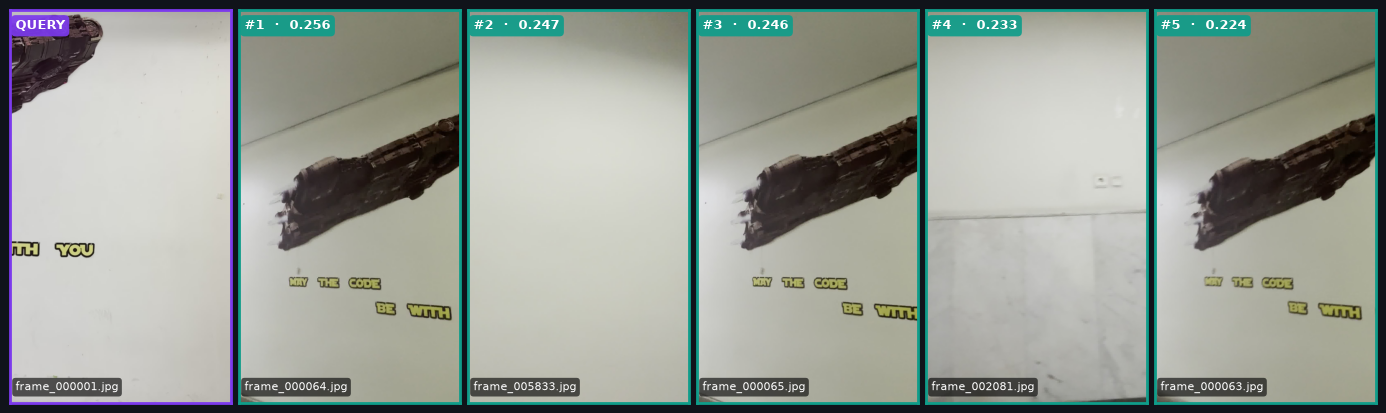

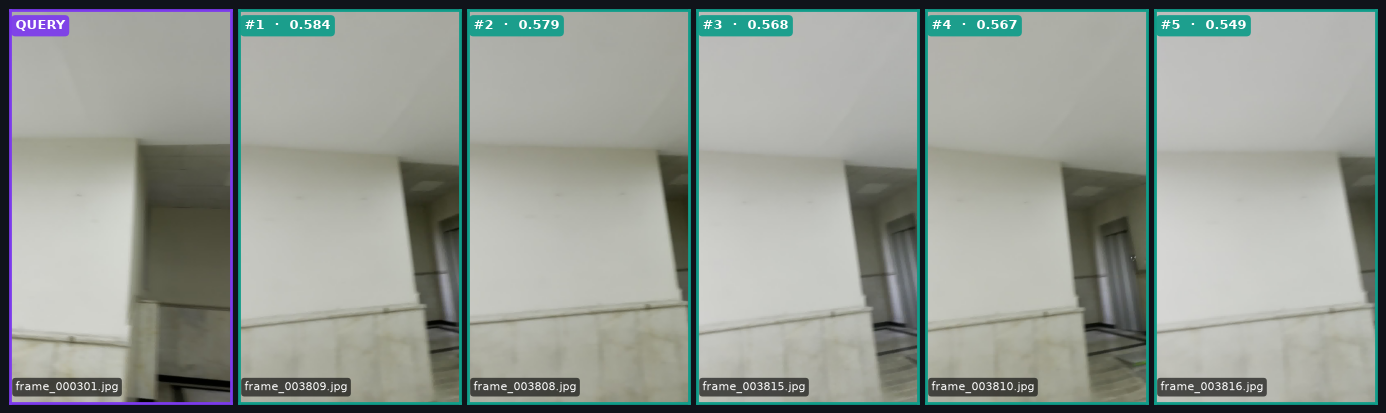

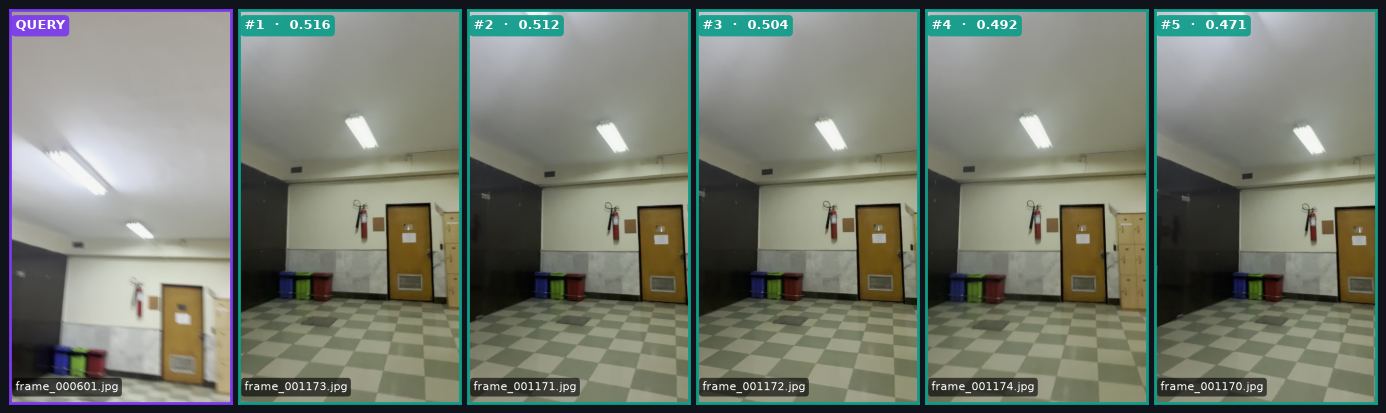

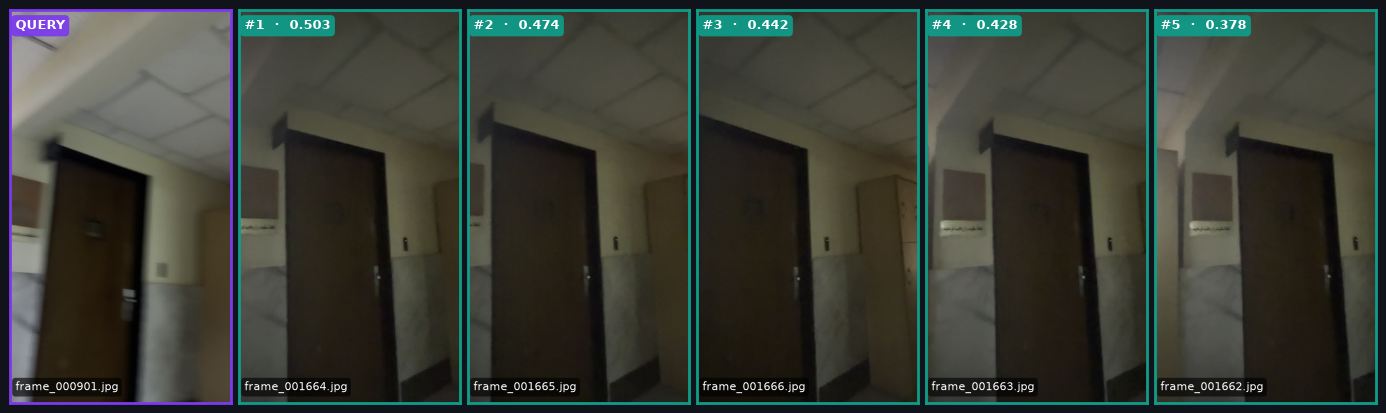

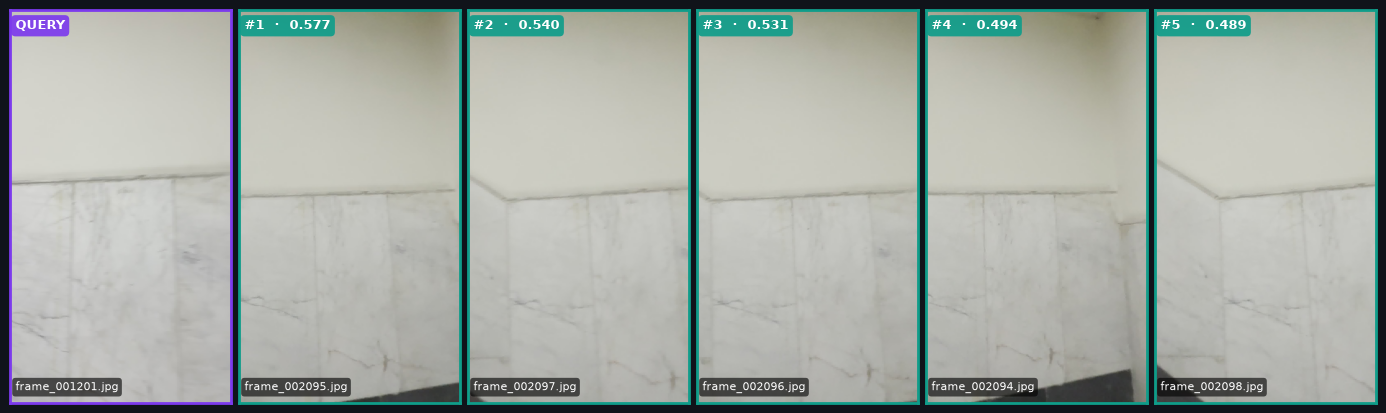

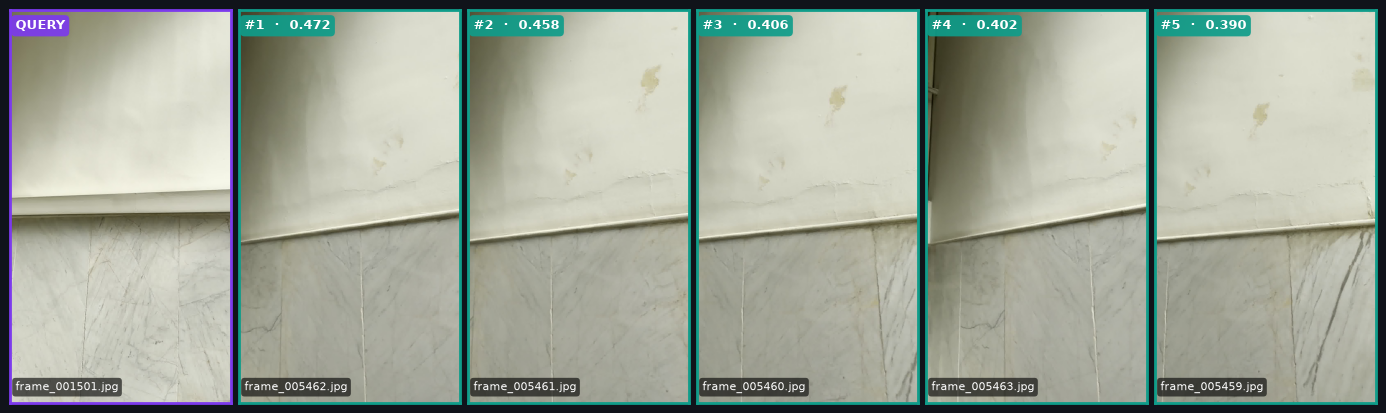

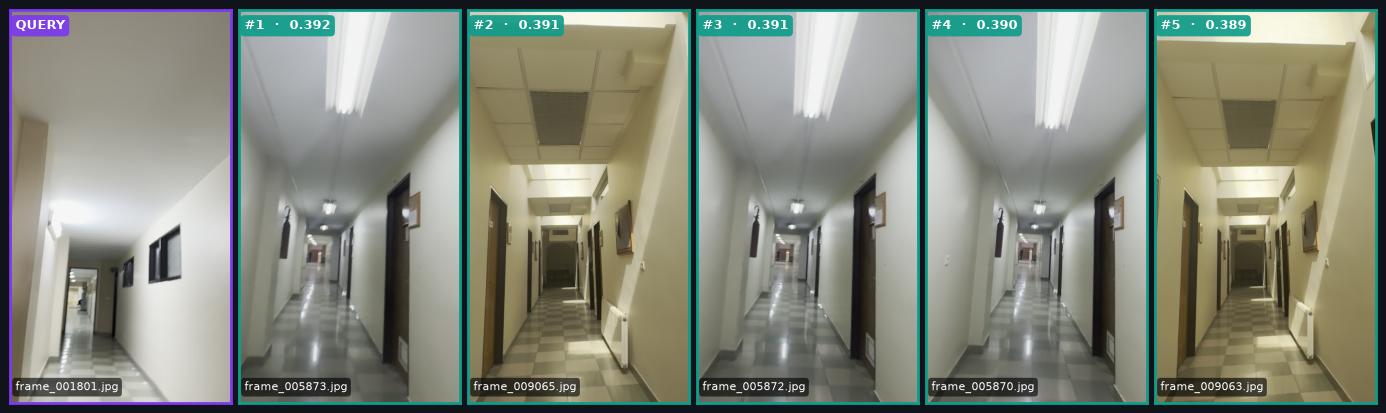

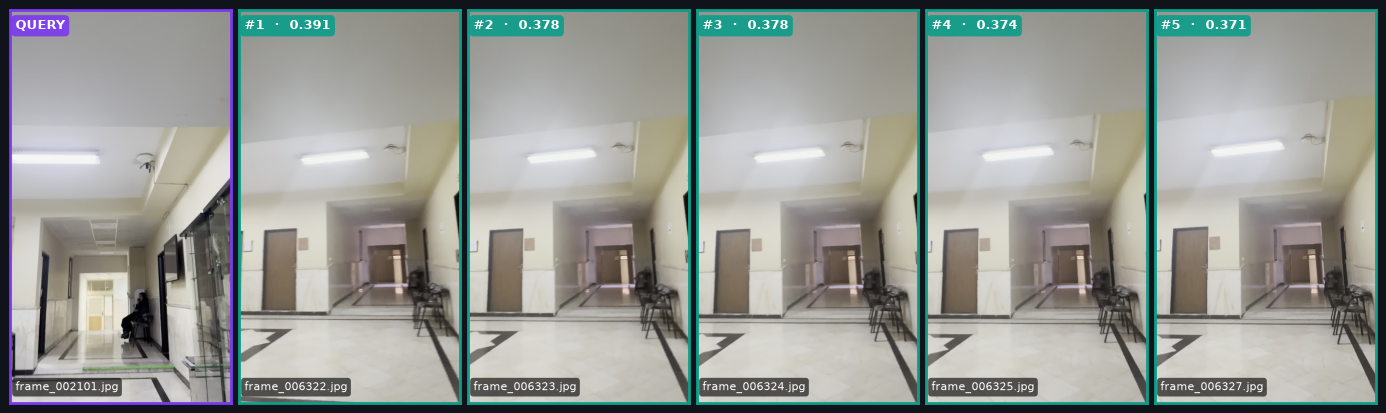

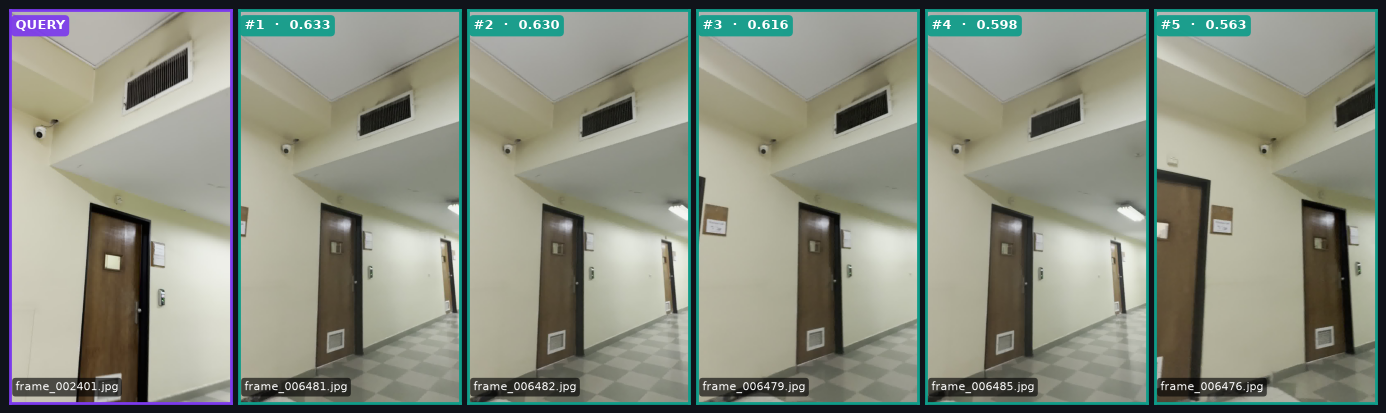

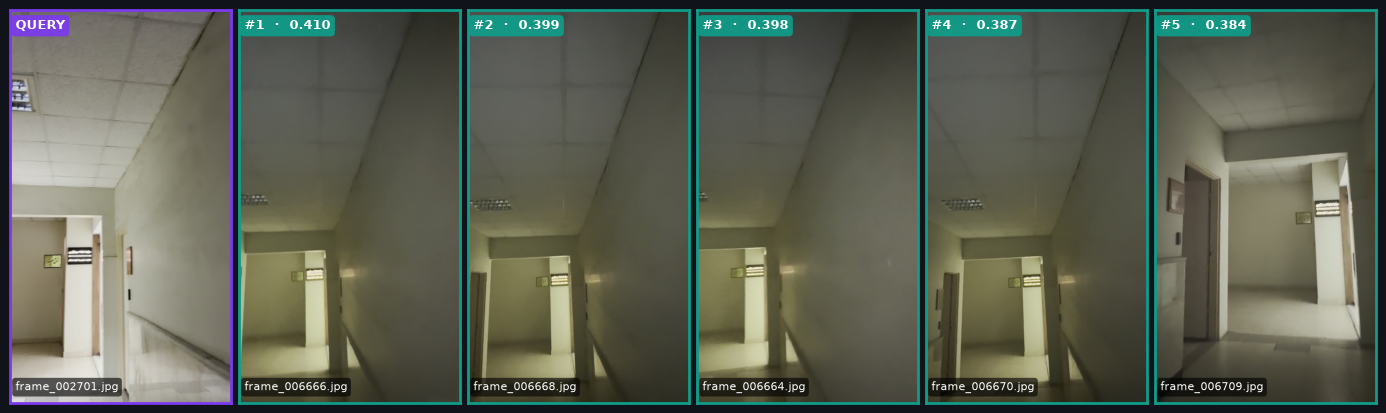

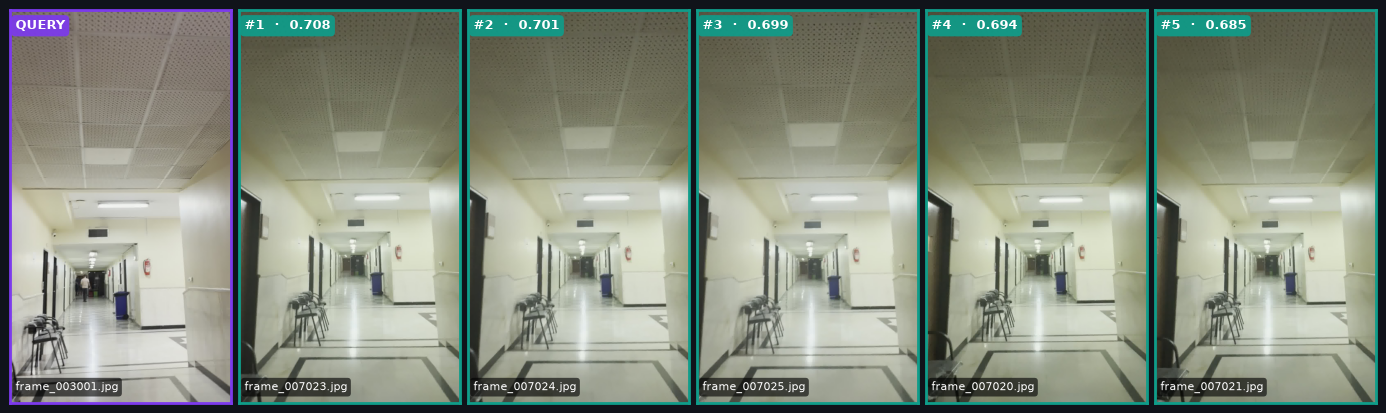

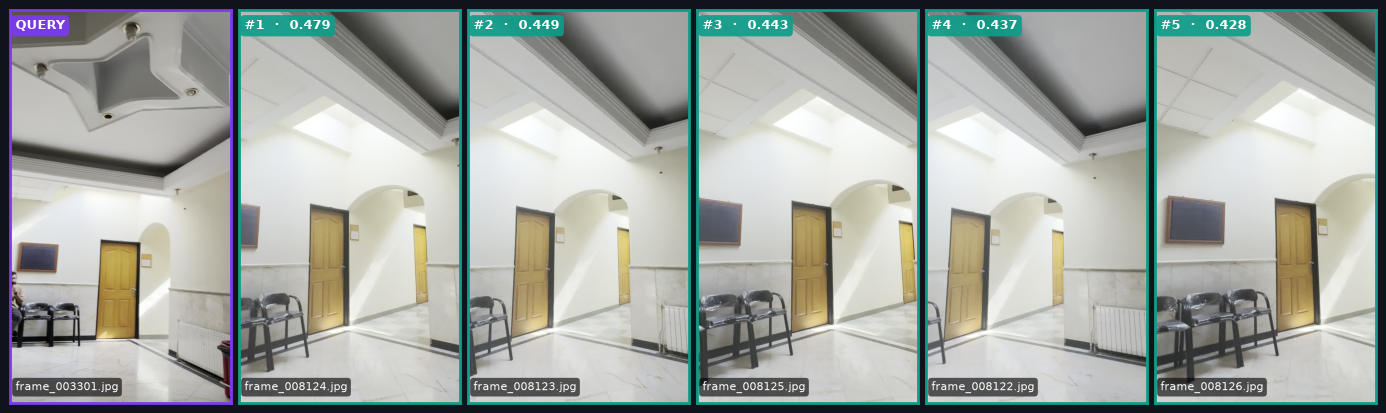

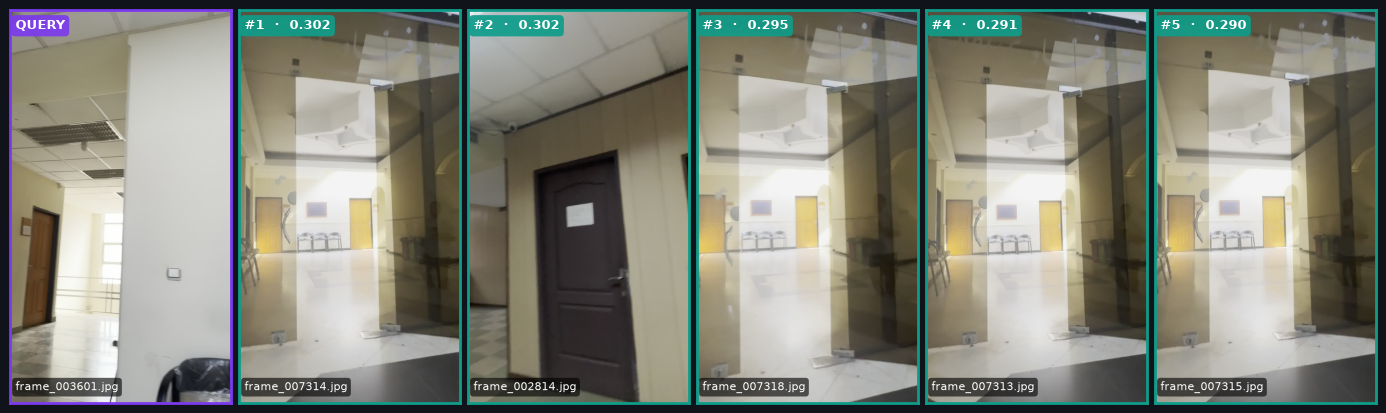

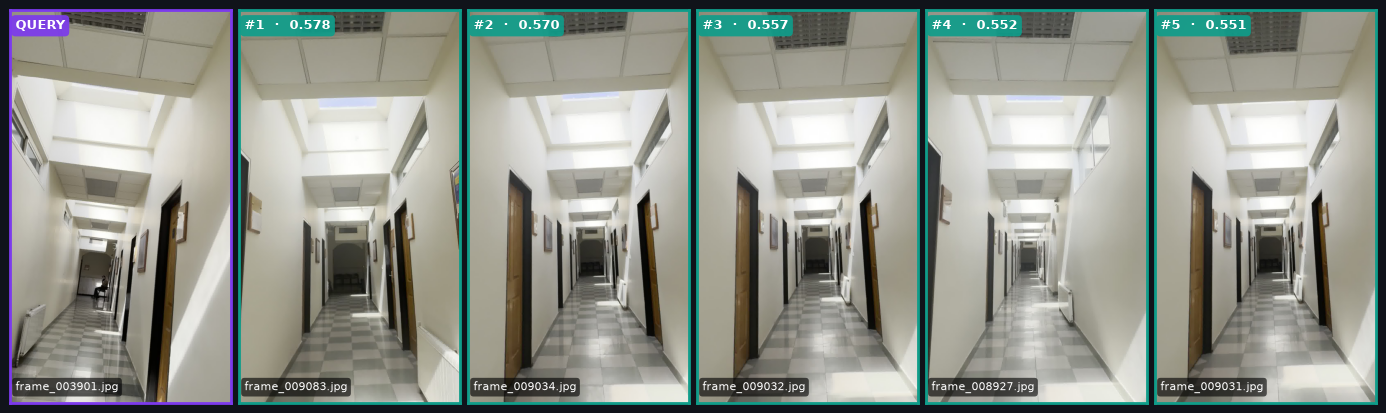

: 

In [ ]:
from pathlib import Path
import csv
import sys

import numpy as np

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from indoor_vpr import DatasetConfig, ImageDataset
from indoor_vpr.visualization import show_matches

# Keep this block in sync with the Configuration section if you change the experiment.
ALGORITHM = 'mixvpr'
DATASET_ROOT = PROJECT_ROOT / 'datasets' / 'dataset-2'
DATABASE_DIR = DATASET_ROOT / 'frames-IMG_3609'
QUERY_DIR = DATASET_ROOT / 'frames-IMG_3610'
MAX_DATABASE_IMAGES = None
MAX_QUERY_IMAGES = None
TOP_K = 5
SIMILARITY_CSV_PATH = PROJECT_ROOT / 'outputs' / f'_{ALGORITHM}_similarity.csv'

dataset_config = DatasetConfig(
    database_dir=DATABASE_DIR,
    query_dir=QUERY_DIR,
    max_database_images=MAX_DATABASE_IMAGES,
    max_query_images=MAX_QUERY_IMAGES,
)
dataset = ImageDataset.from_config(dataset_config)

if not SIMILARITY_CSV_PATH.is_file():
    raise FileNotFoundError(f'Similarity CSV not found: {SIMILARITY_CSV_PATH}')

class CSVSimilarityView:
    def __init__(self, csv_path: Path, query_count: int, database_count: int) -> None:
        self.csv_path = Path(csv_path)
        self.query_count = query_count
        self.database_count = database_count
        self._row_cache: dict[int, np.ndarray] = {}

    @property
    def shape(self) -> tuple[int, int]:
        return self.query_count, self.database_count

    def row(self, query_index: int) -> np.ndarray:
        if not 0 <= query_index < self.query_count:
            raise IndexError(f"query_index must be between 0 and {self.query_count - 1}")
        if query_index in self._row_cache:
            return self._row_cache[query_index]
        with self.csv_path.open(newline="") as handle:
            reader = csv.reader(handle)
            header = next(reader, None)
            if header is None:
                raise ValueError(f"Similarity CSV is empty: {self.csv_path}")
            for row_number, row in enumerate(reader):
                if row_number == query_index:
                    values = np.asarray(row[2:], dtype=np.float32)
                    self._row_cache[query_index] = values
                    return values
        raise IndexError(f"query_index out of range for CSV: {query_index}")

    def __getitem__(self, key):
        query_index, database_index = key
        return float(self.row(int(query_index))[int(database_index)])

class CSVBackedResults:
    def __init__(self, dataset, similarity):
        self.dataset = dataset
        self.similarity = similarity

    def top_indices(self, query_index: int, top_k: int = 5) -> np.ndarray:
        row = self.similarity.row(query_index)
        if top_k >= len(row):
            return np.argsort(-row)
        candidate_indices = np.argpartition(row, -top_k)[-top_k:]
        return candidate_indices[np.argsort(-row[candidate_indices])]

inspect_results = CSVBackedResults(
    dataset=dataset,
    similarity=CSVSimilarityView(SIMILARITY_CSV_PATH, len(dataset.query_paths), len(dataset.database_paths)),
)

QUERY_INDEX = 5  # Change this to inspect another query.
for i in range(0, 4000, 300):
    show_matches(inspect_results, query_index=i, top_k=TOP_K)
